In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import warnings

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Buat folder jika belum ada
os.makedirs('../output', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 1. Load Data
print("Memuat dataset...")
df_train = pd.read_csv('../processed/train_2d.csv')
df_test_full = pd.read_csv('../processed/test_full.csv') 
df_test_true = pd.read_csv('../processed/test_2d.csv')

print("Data berhasil dimuat!")

Memuat dataset...
Data berhasil dimuat!


### Feature Engineering (Rolling Features)

In [29]:
base_features = [c for c in df_train.columns if c not in ['unit_number', 'time_cycles', 'RUL']]

def add_rolling_features(df, feature_cols, window=10):
    df_out = df.copy()
    roll_feats = []
    for col in feature_cols:
        roll_mean = df_out.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        roll_std  = df_out.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
        df_out[f'{col}_rmean'] = roll_mean
        df_out[f'{col}_rstd']  = roll_std
        roll_feats += [f'{col}_rmean', f'{col}_rstd']
    return df_out, roll_feats

print("Hitung rolling features...")
df_train_feat, new_feats = add_rolling_features(df_train, base_features, window=10)
df_test_feat, _ = add_rolling_features(df_test_full, base_features, window=10)

# Potong Test menjadi baris terakhir saja
df_test_feat_last = df_test_feat.groupby('unit_number').last().reset_index()

# Kumpulkan semua fitur
all_feats = base_features + new_feats

# Siapkan X dan y
X_train = df_train_feat[all_feats].values
y_train = df_train_feat['RUL'].values

X_test = df_test_feat_last[all_feats].values
y_test = df_test_true['RUL_True'].values 

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")

Hitung rolling features...
Bentuk X_train: (20631, 51)
Bentuk X_test : (100, 51)


### Training XGBoost

In [30]:
xgb_params = {
    'n_estimators'     : 500,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 3,
    'reg_alpha'        : 0.1,   
    'reg_lambda'       : 1.0,   
    'random_state'     : 42,
    'n_jobs'           : -1,
    'early_stopping_rounds': 30
}

# Split 10% data latih untuk early stopping
val_split = int(0.9 * len(X_train))
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

xgb_model = XGBRegressor(**xgb_params)

print('Melatih model XGBoost...')
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=50 
)

Melatih model XGBoost...
[0]	validation_0-rmse:40.02117	validation_1-rmse:39.79919
[50]	validation_0-rmse:15.53210	validation_1-rmse:18.58177
[100]	validation_0-rmse:13.25808	validation_1-rmse:18.29539
[115]	validation_0-rmse:12.70951	validation_1-rmse:18.32107


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

### Evaluasi & Plotting


=== Evaluasi XGBoost (Data Uji) ===
RMSE       : 19.4273
MAE        : 14.0989
R2 Score   : 0.7814
NASA Score : 1305.5113


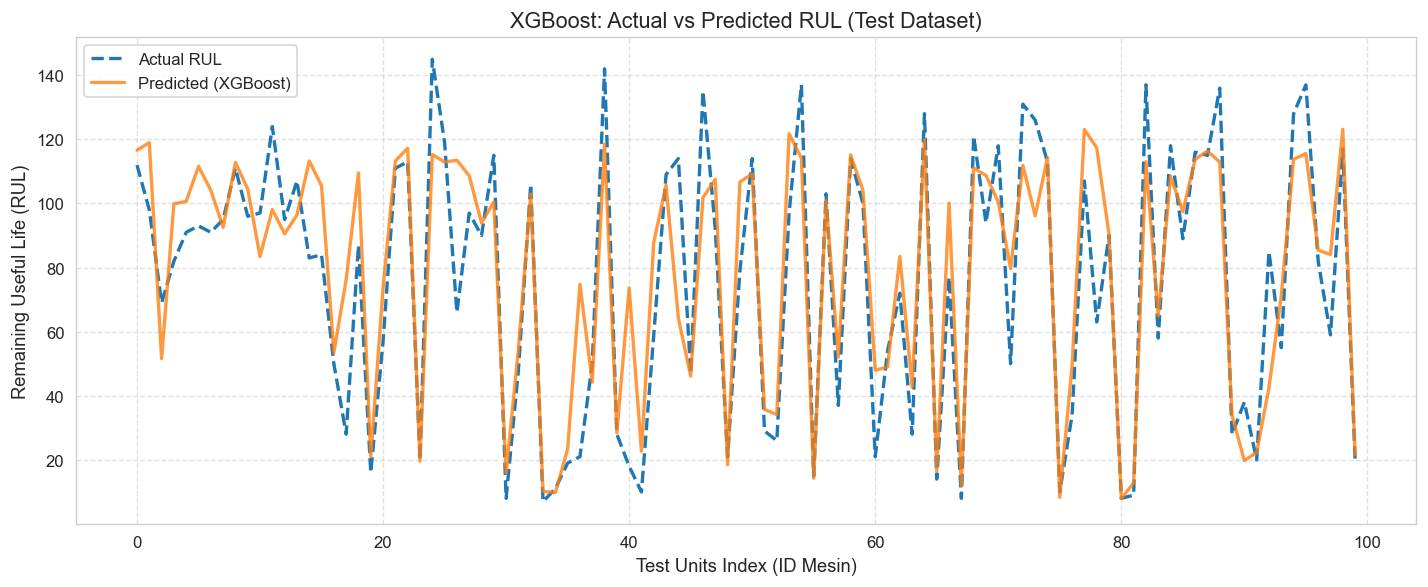

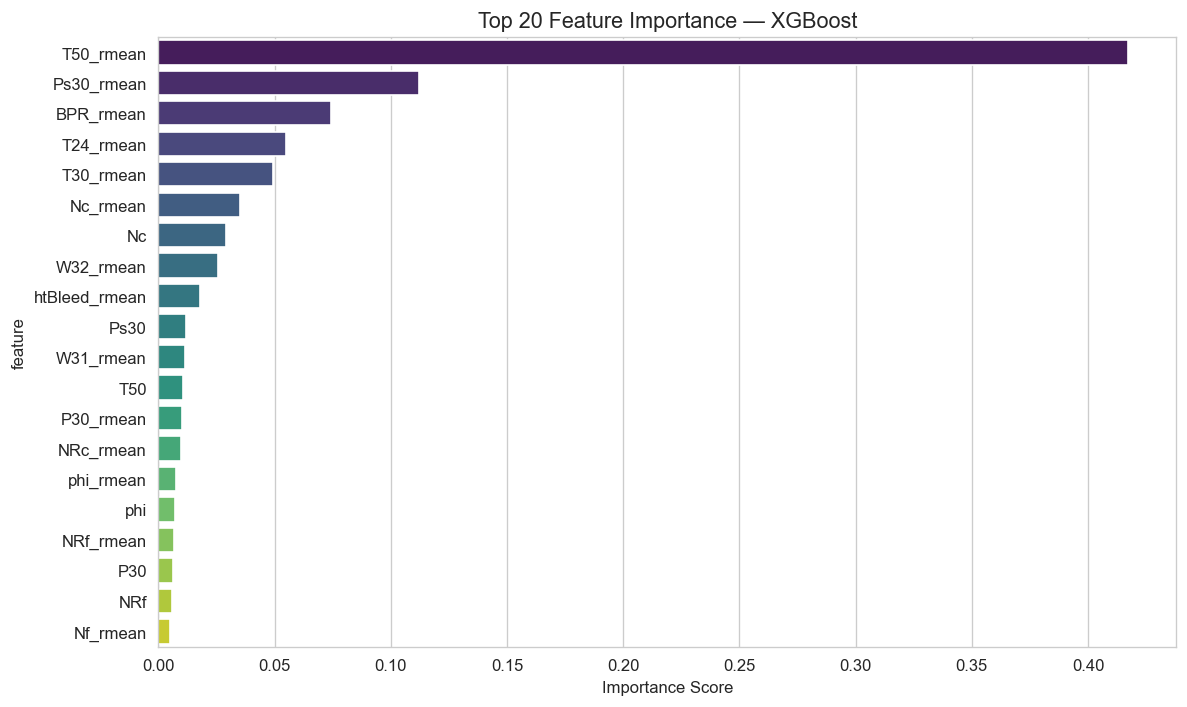

In [31]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # NASA scoring function
    def nasa_score(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    ns = nasa_score(y_true, y_pred)
    
    print(f'\n=== Evaluasi {model_name} (Data Uji) ===')
    print(f'RMSE       : {rmse:.4f}')
    print(f'MAE        : {mae:.4f}')
    print(f'R2 Score   : {r2:.4f}')
    print(f'NASA Score : {ns:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NASA_Score': float(ns)}

# 1. Prediksi Data Test
y_pred_xgb = xgb_model.predict(X_test)
metrics_xgb = evaluate_model(y_test, y_pred_xgb, model_name='XGBoost')

# 2. Plot Prediksi vs Aktual
plt.figure(figsize=(12, 5))

# Catatan: y_test kita sudah berbentuk numpy array, jadi tidak perlu ditambah .values
plt.plot(y_test, label='Actual RUL', linestyle='--', color='#1f77b4', linewidth=2)
plt.plot(y_pred_xgb, label='Predicted (XGBoost)', color='#ff7f0e', alpha=0.8, linewidth=2)

plt.title('XGBoost: Actual vs Predicted RUL (Test Dataset)', fontsize=13)
plt.xlabel('Test Units Index (ID Mesin)', fontsize=11)
plt.ylabel('Remaining Useful Life (RUL)', fontsize=11)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../output/xgb_pred_vs_actual_line.png', dpi=300)
plt.show()

# 3. Feature Importance
importance_df = pd.DataFrame({
    'feature': all_feats,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importance — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../output/xgb_feature_importance.png', dpi=300)
plt.show()

### Simpan model

In [32]:
# Simpan model 
joblib.dump(xgb_model, '../models/xgb_model.pkl')

# Simpan hasil prediksi
pred_df = pd.DataFrame({'unit_number': df_test_true['unit_number'], 'y_true': y_test, 'y_pred_xgb': y_pred_xgb})
pred_df.to_csv('../processed/xgb_predictions.csv', index=False)

# Simpan metrik evaluasi
with open('../processed/xgb_metrics.json', 'w') as f:
    json.dump(metrics_xgb, f, indent=2)

print("Model, Prediksi, dan Metrik XGBoost berhasil disimpan!")

Model, Prediksi, dan Metrik XGBoost berhasil disimpan!
